In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import cv2
from glob import glob

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
DATA_DIR = "C:\\Users\\CorteC\\Documents\\MS_Codes_Python\\S8\\ImageAnalysis(WORKSHOP)\\brain_tumor_dataset" 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.0001
no_tumor_path = os.path.join(DATA_DIR, 'no')
yes_tumor_path = os.path.join(DATA_DIR, 'yes')
no_images = glob(os.path.join(no_tumor_path, '*.*'))
yes_images = glob(os.path.join(yes_tumor_path, '*.*'))
print(f"Number of 'no tumor' images: {len(no_images)}")
print(f"Number of 'yes tumor' images: {len(yes_images)}")

Number of 'no tumor' images: 98
Number of 'yes tumor' images: 155


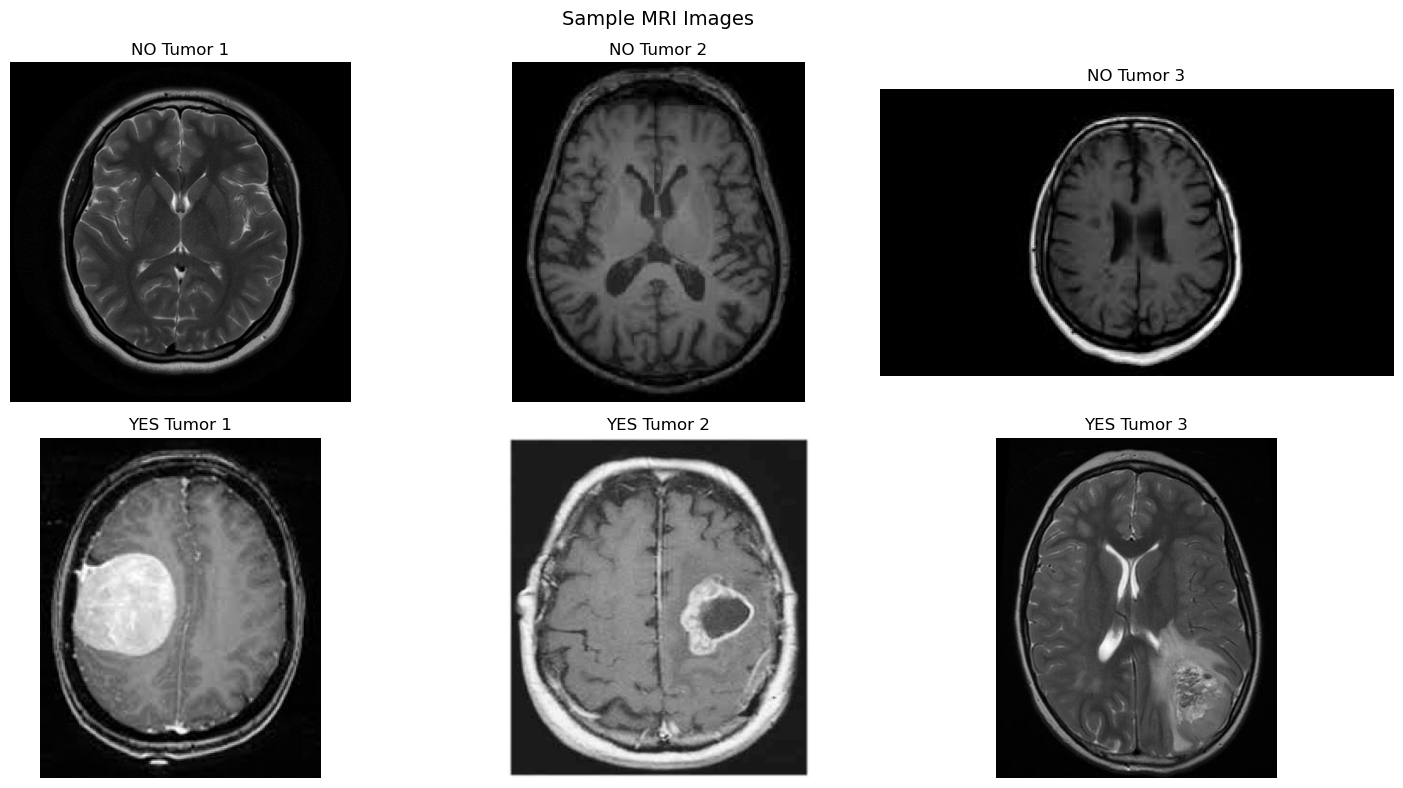

In [9]:
def display_samples(no_images, yes_images, num_samples):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))
    for i in range(num_samples):
        img_path = no_images[i]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"NO Tumor {i+1}")
        axes[0, i].axis('off')
    
    for i in range(num_samples):
        img_path = yes_images[i]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"YES Tumor {i+1}")
        axes[1, i].axis('off')
    
    plt.suptitle("Sample MRI Images", fontsize=14)
    plt.tight_layout()
    plt.show()

display_samples(no_images, yes_images , 3)

In [10]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['no', 'yes']  
)

validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['no', 'yes']
)

print(f"Class indices: {train_generator.class_indices}")

Found 203 images belonging to 2 classes.


Found 50 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


In [11]:
def create_model():
    base_model = ResNet50V2(weights='imagenet',include_top=False,input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    
    return model, base_model

model, base_model = create_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,369 (92.02 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_brain_tumor_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


c:\Users\CorteC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4803 - auc: 0.5303 - loss: 0.8894 - precision: 0.6952 - recall: 0.3948
Epoch 1: val_accuracy improved from -inf to 0.68750, saving model to best_brain_tumor_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 57s 5s/step - accuracy: 0.4827 - auc: 0.5278 - loss: 0.8817 - precision: 0.6848 - recall: 0.4072 - val_accuracy: 0.6875 - val_auc: 0.9069 - val_loss: 0.6084 - val_precision: 0.5714 - val_recall: 0.9231 - learning_rate: 1.0000e-04
Epoch 2/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5938 - auc: 0.7202 - loss: 0.6309 - precision: 0.6316 - recall: 0.6667

c:\Users\CorteC\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.68750 to 0.71875, saving model to best_brain_tumor_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 840ms/step - accuracy: 0.5938 - auc: 0.7202 - loss: 0.6309 - precision: 0.6316 - recall: 0.6667 - val_accuracy: 0.7188 - val_auc: 0.9190 - val_loss: 0.6124 - val_precision: 0.5909 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5518 - auc: 0.5744 - loss: 0.7702 - precision: 0.5907 - recall: 0.7348
Epoch 3: val_accuracy did not improve from 0.71875
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5565 - auc: 0.5755 - loss: 0.7640 - precision: 0.6007 - recall: 0.7286 - val_accuracy: 0.6875 - val_auc: 0.9514 - val_loss: 0.5975 - val_precision: 0.5652 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5938 - auc: 0.4784 - loss: 0.7720 - precision: 0.5769 - recall: 0.8824
Epoch 4: val_accuracy did not improve from 0.71875
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 590ms/step - accuracy: 0.5938 - auc: 0.4784 - loss: 0.7720 - precision: 0.5769 - recall: 0.88

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6699 - auc: 0.6644 - loss: 0.6362 - precision: 0.6871 - recall: 0.8516 - val_accuracy: 0.7812 - val_auc: 0.9737 - val_loss: 0.5319 - val_precision: 0.6500 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6250 - auc: 0.6348 - loss: 0.6961 - precision: 0.5909 - recall: 0.8125
Epoch 6: val_accuracy did not improve from 0.78125
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 572ms/step - accuracy: 0.6250 - auc: 0.6348 - loss: 0.6961 - precision: 0.5909 - recall: 0.8125 - val_accuracy: 0.7812 - val_auc: 0.9737 - val_loss: 0.5199 - val_precision: 0.6500 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6572 - auc: 0.6535 - loss: 0.6692 - precision: 0.6591 - recall: 0.8424
Epoch 7: val_accuracy improved from 0.78125 to 0.90625, saving model to best_brain_tumor_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6561 - auc: 0.6555 - loss: 0.6656 - precision: 0.6622 - recall: 0.8344 - val_accuracy: 0.9062 - val_auc: 0.9737 - val_loss: 0.4487 - val_precision: 0.8571 - val_recall: 0.9231 - learning_rate: 1.0000e-04
Epoch 8/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.7500 - auc: 0.7100 - loss: 0.6289 - precision: 0.8421 - recall: 0.7619
Epoch 8: val_accuracy did not improve from 0.90625
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 545ms/step - accuracy: 0.7500 - auc: 0.7100 - loss: 0.6289 - precision: 0.8421 - recall: 0.7619 - val_accuracy: 0.9062 - val_auc: 0.9757 - val_loss: 0.4421 - val_precision: 0.8571 - val_recall: 0.9231 - learning_rate: 1.0000e-04
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6729 - auc: 0.7191 - loss: 0.5891 - precision: 0.7310 - recall: 0.7685
Epoch 9: val_accuracy did not improve from 0.90625
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6678 - auc: 0.7163 - loss: 0.5922 - precision: 0.7269 - recall: 0.7645

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6884 - auc: 0.7327 - loss: 0.5727 - precision: 0.7215 - recall: 0.8080 - val_accuracy: 0.9688 - val_auc: 0.9960 - val_loss: 0.3930 - val_precision: 0.9286 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 12/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6562 - auc: 0.7490 - loss: 0.6041 - precision: 0.7222 - recall: 0.6842
Epoch 12: val_accuracy did not improve from 0.96875
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 506ms/step - accuracy: 0.6562 - auc: 0.7490 - loss: 0.6041 - precision: 0.7222 - recall: 0.6842 - val_accuracy: 0.9688 - val_auc: 0.9960 - val_loss: 0.3901 - val_precision: 0.9286 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 13/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6831 - auc: 0.7580 - loss: 0.5497 - precision: 0.7425 - recall: 0.7706
Epoch 13: val_accuracy did not improve from 0.96875
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.6858 - auc: 0.7601 - loss: 0.5488 - precision: 0.7429 - recall: 0.

6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.7429 - auc: 0.8329 - loss: 0.5024 - precision: 0.7666 - recall: 0.8212 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2990 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 22/30
1/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4545 - auc: 0.5667 - loss: 0.7285 - precision: 0.4000 - recall: 0.4000
Epoch 22: val_accuracy did not improve from 1.00000
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 746ms/step - accuracy: 0.4545 - auc: 0.5667 - loss: 0.7285 - precision: 0.4000 - recall: 0.4000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2976 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 23/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7374 - auc: 0.8289 - loss: 0.4881 - precision: 0.7814 - recall: 0.8020
Epoch 23: val_accuracy did not improve from 1.00000
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7373 - auc: 0.8289 - loss: 0.4885 - precision: 0.7788 - recall: 0.8